# **다중 감성 분석 순환 신경망 모델**

In [2]:
!pip install koreanize_matplotlib
import koreanize_matplotlib

import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras; import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.layers import Input, Dense, Embedding, SimpleRNN, GRU, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback, EarlyStopping
import warnings; warnings.filterwarnings('ignore')

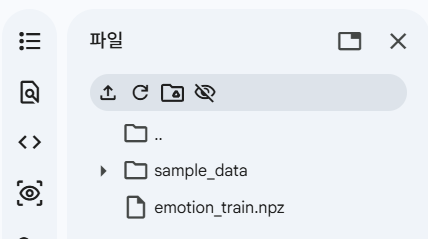

In [3]:
# 데이터 불러오기
data = np.load("emotion_train.npz", allow_pickle=True)
texts = data["texts"]
labels = data["labels"]

# 출력
print(texts[:5])
print()
print(labels[:5])


['i didnt feel humiliated'
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'
 'im grabbing a minute to post i feel greedy wrong'
 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property'
 'i am feeling grouchy']

[0 0 3 2 3]


In [4]:
# 감정 라벨 빈도 표시
classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(f"Label {c}: {n}")

Label 0: 4666
Label 1: 5362
Label 2: 1304
Label 3: 2159
Label 4: 1937
Label 5: 572


In [5]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
vocab_size=len(tokenizer.word_index) + 1  # 0은 패딩용 특수 목적 토큰
print("토큰 수:", vocab_size)
print(tokenizer.index_word)
text_encoded = tokenizer.texts_to_sequences(texts)
seq_length = max(len(seq) for seq in text_encoded)
print("최대 길이=", seq_length); print()

X = pad_sequences(text_encoded,
                  maxlen=seq_length,
                  padding='pre')
print("X shape:", X.shape)
print(X); print()

y=labels
print("y shape:", y.shape)
print(y)

토큰 수: 15213
{1: 'i', 2: 'feel', 3: 'and', 4: 'to', 5: 'the', 6: 'a', 7: 'feeling', 8: 'that', 9: 'of', 10: 'my', 11: 'in', 12: 'it', 13: 'like', 14: 'so', 15: 'for', 16: 'im', 17: 'me', 18: 'but', 19: 'was', 20: 'have', 21: 'is', 22: 'this', 23: 'am', 24: 'with', 25: 'not', 26: 'about', 27: 'be', 28: 'as', 29: 'on', 30: 'you', 31: 'just', 32: 'at', 33: 'when', 34: 'or', 35: 'all', 36: 'because', 37: 'more', 38: 'do', 39: 'can', 40: 'really', 41: 'up', 42: 't', 43: 'are', 44: 'by', 45: 'very', 46: 'know', 47: 'been', 48: 'if', 49: 'out', 50: 'myself', 51: 'time', 52: 'how', 53: 'what', 54: 'get', 55: 'little', 56: 'had', 57: 'now', 58: 'will', 59: 'from', 60: 'being', 61: 'they', 62: 'people', 63: 'them', 64: 'would', 65: 'he', 66: 'want', 67: 'her', 68: 'some', 69: 'think', 70: 'one', 71: 'still', 72: 'ive', 73: 'him', 74: 'even', 75: 'who', 76: 'an', 77: 'life', 78: 'its', 79: 'make', 80: 'there', 81: 'we', 82: 'bit', 83: 'something', 84: 'love', 85: 'much', 86: 'going', 87: 'dont', 8

In [9]:
#  랜덤 시드 고정 (결과 일관성 보장)
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 데이터 분할
x_train, x_test, y_train, y_test, x_train_text, x_test_text  = train_test_split(
    X, y, texts, test_size=0.2, random_state=SEED)

# 모델 설정
embedding_dim=128
감성6=Sequential([
    Input(shape=(seq_length,)),       # shape에 주의
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    GRU(64, return_sequences=False),  # 마지막 스텝의 출력만 사용
    Dropout(0.2),
    Dense(6, activation='softmax')    # 6개의 감정 유형
    ])
early_stop=EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True )
감성6.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history=감성6.fit(x_train, y_train, epochs=30, validation_data=(x_test, y_test), callbacks=[early_stop])

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3340 - loss: 1.6440 - val_accuracy: 0.3194 - val_loss: 1.5772
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3717 - loss: 1.5351 - val_accuracy: 0.3713 - val_loss: 1.5345
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4363 - loss: 1.4000 - val_accuracy: 0.4684 - val_loss: 1.3184
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5627 - loss: 1.1159 - val_accuracy: 0.5500 - val_loss: 1.1279
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6685 - loss: 0.8863 - val_accuracy: 0.6509 - val_loss: 0.9323
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7616 - loss: 0.7073 - val_accuracy: 0.7094 - val_loss: 0.8199
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8112 - loss: 0.6034 - val_accuracy: 0.7459 - val_loss: 0.7455
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8491 - loss: 0.5090 - val_accuracy: 

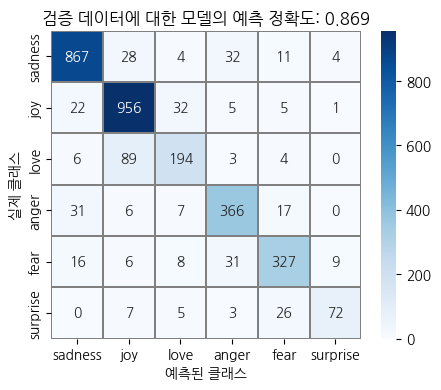

In [10]:
class_label=["sadness","joy","love","anger","fear", "surprise"] # 감정 클래스 이름(순서에 주의)
y_prob = 감성6.predict(x_test, verbose=0)
y_pred=np.argmax(y_prob, axis=1)     # 예측 감성 유형

# 정확도 및 혼동 행렬 시각화
acc=accuracy_score(y_test, y_pred)
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',linewidths=0.1, linecolor="gray",  cmap='Blues',
            xticklabels=class_label, yticklabels=class_label)
plt.title(f'검증 데이터에 대한 모델의 예측 정확도: {acc:.3f}')
plt.ylabel('실제 클래스'); plt.xlabel('예측된 클래스'); plt.show()

In [11]:
# 5개 샘플 무작위로 선택
sample_index=random.sample(range(len(x_test_text)), 5)
print("감성 예측 결과 (랜덤 5개):")
for i in sample_index:
    print(f"리뷰: {x_test_text[i]}")
    print(f"실제: {class_label[y_test[i]]}")
    print(f"예측: {class_label[y_pred[i]]}")
    print("-" * 50)

감성 예측 결과 (랜덤 5개):
리뷰: i notice myself worrying about him i push that feeling away and replace the thought with something positive or remind myself to let go its out of my control
실제: joy
예측: joy
--------------------------------------------------
리뷰: i am feeling a little overwhelmed but ive been given some amazing tools met some wonderfully creative fun and crazy people and was reminded that i have a voice that has been silent for too long
실제: surprise
예측: fear
--------------------------------------------------
리뷰: i can get away these days with the gag line when i feel like being sarcastic that i feel sorry for anyone who wasn t fortunate enough to be born mexican
실제: anger
예측: sadness
--------------------------------------------------
리뷰: i wanna scream out my feelings that i keep until it bleeds the life is sometimes prejudiced it kills happiness thus it becomes even worst feeling like the life is now meaningless why should i be the victim
실제: sadness
예측: sadness
-------------------